In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import xobjects as xo
import xpart as xp
import xcoll as xc
import json

In [25]:
line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

qx = 20.13
qy = 20.18
xi_x = 0.5
xi_y = 0.5

line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
        ],
    )
tw_ref = line.twiss()

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 14.2                              
Matching: model call n. 15 penalty = 6.3976e-06              
Optimize - end penalty:  6.39758e-06                            


Turning off sextupoles

In [26]:
tt_vars = line.vars.get_table()
for kk in tt_vars.rows['kls.*'].name:
    line[kk] = 0.0

for kk in tt_vars.rows['kl.*'].name:
    line[kk] = 0.0
for kk in tt_vars.rows['ks.*'].name:
    line[kk] = 0.0
tw = line.twiss()
tw.qx, tw.qy, tw.dqx, tw.dqy

(np.float64(20.130029320948722),
 np.float64(20.180030229082664),
 np.float64(-22.664668975699243),
 np.float64(-22.75062495235352))

In [22]:
np.min(np.abs(tw.dx))
np.argmin(np.abs(tw.dx))

np.int64(2314)

In [23]:
tw.name[np.argmin(np.abs(tw.dx))]

'mba.11570..1_aper2'

In [27]:
num_particles  = 100
num_turns = 6000

sweep = 3000
plane = 'DPpos'
sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224

In [28]:
part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                          nemitt_y=nemitt_y,
                                          sigma_z=sigma_z, num_particles=num_particles, line=line)

*** Maximum RMS bunch length 0.23610110400434295m.
... distance to target bunch length: -2.2226e-01
... distance to target bunch length: 5.5784e-03
... distance to target bunch length: 5.2361e-03
... distance to target bunch length: -6.3267e-03
... distance to target bunch length: 1.9948e-03
... distance to target bunch length: -3.8258e-04
... distance to target bunch length: 5.3833e-05
... distance to target bunch length: 1.2594e-06
... distance to target bunch length: -1.0995e-10
... distance to target bunch length: 1.2805e-07
--> Bunch length: 0.22399999989004865
--> Emittance: 0.279717871043194


In [29]:
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
rf_sweep = xc.RFSweep(line)
rf_sweep.prepare(sweep_per_turn=sweep/num_turns)
rf_sweep.info()

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Slicing line:   0%|          | 0/32538 [00:00<?, ?it/s]

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Enabled time-dependent variables in the line.
The current frequency is 199999999.5Hz, adding -0.5Hz per turn.
This sweep will move the center of the bucket with Δδ = 1.394e-06 per turn.
The bucket height is 0.002982, so this implies the sweep will shift one bucket every 4278.19 turns.


In [30]:
line.scattering.enable()
line.track(particles=part, num_turns=num_turns, time=True, with_progress=5)
line.scattering.disable()

No xcoll elements found in line.


Tracking:   0%|          | 0/6000 [00:00<?, ?it/s]

No xcoll elements found in line.


In [31]:
def df_to_delta(df_hz: np.ndarray | float) -> np.ndarray | float:
    sps_gtr = 17.95
    sps_g0 = 27.643
    f0 = 200e6
    eta = 1 / sps_gtr**2 - 1 / sps_g0**2
    return -np.asarray(df_hz) / (f0 * eta)

In [32]:
turns, counts = np.unique(part.at_turn, return_counts=True)

turns = np.concatenate(([0], turns))
counts = np.concatenate(([0], counts))
deltas = df_to_delta(turns * sweep / num_turns)

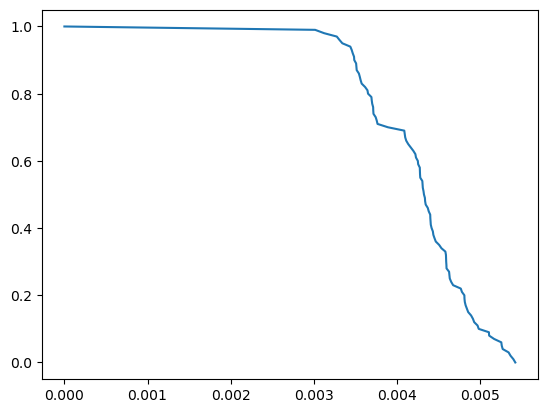

In [33]:
fig, ax = plt.subplots()
ax.plot(deltas, 1 - np.cumsum(counts) / num_particles)

In [37]:
for idx in np.unique(part.at_element):
    print(f'{line.element_names[idx]}')

vcak.10101.a_aper
vcak.11101.a_aper
vcak.32501.a_aper
vcak.40101.a_aper
vcak.41101.a_aper
vcak.52501.a_aper
vcak.53501.a_aper
vcak.60101.a_aper
vcak.61101.a_aper
vttw.61402.a_aper
vttw.61402.b_aper


In [24]:
dico = {'DPneg' : {'deltas' : deltas.copy(), 'survival' : 1 - np.cumsum(counts.copy()) / num_particles}}

In [28]:
dico['DPpos'] = {'deltas' : deltas.copy(), 'survival' : 1 - np.cumsum(counts.copy()) / num_particles}

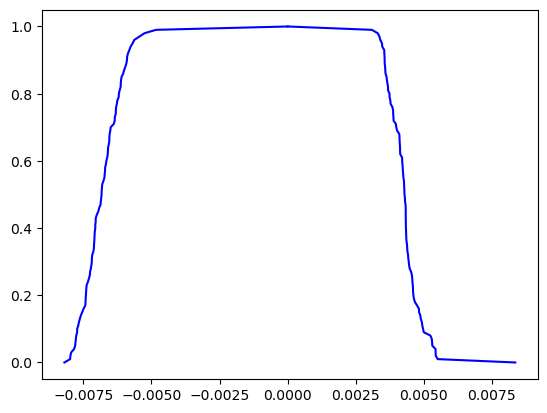

In [29]:
fig, ax = plt.subplots()
ax.plot(dico['DPneg']['deltas'], dico['DPneg']['survival'], color='blue')
ax.plot(dico['DPpos']['deltas'], dico['DPpos']['survival'], color='blue')

In [32]:
tw.ddqx

np.float64(52.712992641070024)

In [38]:
df_to_delta(3000)

np.float64(-0.00835668688757655)

In [39]:
df_to_delta(6000)

np.float64(-0.0167133737751531)

In [41]:
0.5*20.13 * 0.008

0.08052

# 1000 particles test speed

In [2]:
def df_to_delta(df_hz: np.ndarray | float) -> np.ndarray | float:
    sps_gtr = 17.95
    sps_g0 = 27.643
    f0 = 200e6
    eta = 1 / sps_gtr**2 - 1 / sps_g0**2
    return -np.asarray(df_hz) / (f0 * eta)

In [5]:
line.get_elements_of_type(xt.Sextupole)

([Sextupole(k2=0, k2s=0, length=0.42, order=np.int64(5), inv_factorial_order=0.00833, knl=[0., 0., 0., 0., 0., 0.], ksl=[0., 0., 0., 0., 0., 0.], knl_rel=[0.], ksl_rel=[0.], main_is_skew=False, edge_entry_active=np.uint64(0), edge_exit_active=np.uint64(0), num_multipole_kicks=np.int64(0), model='adaptive', integrator='adaptive', radiation_flag=np.int64(0), delta_taper=0, shift_x=0, shift_y=0, shift_s=0, rot_s_rad=0, rot_x_rad=0, rot_y_rad=0, rot_s_rad_no_frame=0, rot_shift_anchor=0),
  Sextupole(k2=0, k2s=0, length=0.423, order=np.int64(5), inv_factorial_order=0.00833, knl=[0., 0., 0., 0., 0., 0.], ksl=[0., 0., 0., 0., 0., 0.], knl_rel=[0.], ksl_rel=[0.], main_is_skew=False, edge_entry_active=np.uint64(0), edge_exit_active=np.uint64(0), num_multipole_kicks=np.int64(0), model='adaptive', integrator='adaptive', radiation_flag=np.int64(0), delta_taper=0, shift_x=0, shift_y=0, shift_s=0, rot_s_rad=0, rot_x_rad=0, rot_y_rad=0, rot_s_rad_no_frame=0, rot_shift_anchor=0),
  Sextupole(k2=0, k2s

In [ ]:
num_particles  = 100
num_turns = 6000

sweep = 3000

nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224


dico = {}
for plane in ['DPneg', 'DPpos']:
    #Loading and preparing the line
    line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
    env = line.env
    cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
    for name in cavity_names:
        line[name].frequency = 200e6
        line[name].lag = 180
        line[name].voltage = 0
    # line['acl.31735'].voltage = 0 #setting 800 cav to 0V
    line['actcse.31632'].voltage = 3.0e6

    qx = 20.13
    qy = 20.18
    xi_x = 0.5
    xi_y = 0.5

    line.match(
            method="6d",
            vary=[
                xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
                xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
            ],
            targets=[
                xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
                xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
            ],
        )
    tw_ref = line.twiss()

    #Turning off the sextupoles
    tt_vars = line.vars.get_table()
    for kk in tt_vars.rows['kls.*'].name:
        line[kk] = 0.0

    for kk in tt_vars.rows['kl.*'].name:
        line[kk] = 0.0
    for kk in tt_vars.rows['ks.*'].name:
        line[kk] = 0.0
    
    tw = line.twiss()
    tw.qx, tw.qy, tw.dqx, tw.dqy

    line.match(
            method="6d",
            vary=[
                xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad")
            ],
            targets=[
                xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune")
            ],
        )
    #Params
    sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

    #Generating the particles
    part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                          nemitt_y=nemitt_y,
                                          sigma_z=sigma_z, num_particles=num_particles, line=line)
    
    #Tracking
    line.discard_tracker()
    line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
    rf_sweep = xc.RFSweep(line)
    rf_sweep.prepare(sweep_per_turn=sweep/num_turns)
    rf_sweep.info()

    line.scattering.enable()
    line.track(particles=part, num_turns=num_turns, time=True, with_progress=5)
    line.scattering.disable()

    turns, counts = np.unique(part.at_turn, return_counts=True)

    turns = np.concatenate(([0], turns))
    counts = np.concatenate(([0], counts))
    deltas = df_to_delta(turns * sweep / num_turns)

    dico[plane] = {'deltas' : deltas.copy(), 'survival' : 1 - np.cumsum(counts.copy()) / num_particles}

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 14.2                              
Matching: model call n. 15 penalty = 6.3976e-06              
Optimize - end penalty:  6.39758e-06                            
                                             
Optimize - start penalty: 0.0004211                         
Matching: model call n. 6 penalty = 5.9134e-10              
Optimize - end penalty:  5.91344e-10                            
*** Maximum RMS bunch length 0.2361011040043429m.
... distance to target bunch length: -2.2226e-01
... distance to target bunch length: 5.5784e-03
... distance to target bunch length: 5.2361e-03
... distance to target bunch length: -6.3267e-03
... distance to target bunch length: 1.9948e-03
... distance to target bunch length: -3.8258e-04
... distance to target bunch length: 5.3833e-05
... distance to target bunch length: 1.2594e-06
... distance to target bunch length: -1.0995e-10
... dis

ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...


...

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Enabled time-dependent variables in the line.
The current frequency is 199999999.5Hz, adding -0.5Hz per turn.
This sweep will move the center of the bucket with Δδ = 1.394e-06 per turn.
The bucket height is 0.002982, so this implies the sweep will shift one bucket every 4278.2 turns.
No xcoll elements found in line.


Tracking:   0%|          | 0/6000 [00:00<?, ?it/s]

No xcoll elements found in line.


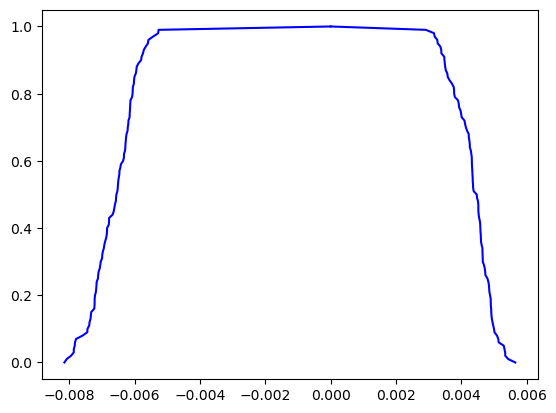

In [4]:
fig, ax = plt.subplots()
ax.plot(dico['DPneg']['deltas'], dico['DPneg']['survival'], color='blue')
ax.plot(dico['DPpos']['deltas'], dico['DPpos']['survival'], color='blue')

This is also turning of mdh, mdv, which are multipoles. Actually they are dipoles, but i also cut them off, so that screws up the orbit correction, which probably makes it unstable

In [14]:
num_particles  = 100
num_turns = 6000

sweep = 3000

nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224

def zero_sextupoles(line: xt.Line) -> None:
    env = line.env
    env.vars["qph_setvalue"] = 0.0
    env.vars["qpv_setvalue"] = 0.0

    tte = env.elements.get_table()
    mask_sextupoles = tte.element_type == "Sextupole"
    sextupole_names = list(tte.rows[mask_sextupoles].name)
    for nn in sextupole_names:
        element = env[nn]
        element.knl = np.zeros_like(np.asarray(element.knl), dtype=float)
        element.ksl = np.zeros_like(np.asarray(element.ksl), dtype=float)

dico = {}
for plane in ['DPneg']:
    #Loading and preparing the line
    line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
    env = line.env
    cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
    for name in cavity_names:
        line[name].frequency = 200e6
        line[name].lag = 180
        line[name].voltage = 0
    # line['acl.31735'].voltage = 0 #setting 800 cav to 0V
    line['actcse.31632'].voltage = 3.0e6

    qx = 20.13
    qy = 20.18
    xi_x = 0.5
    xi_y = 0.5

    line.match(
            method="6d",
            vary=[
                xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
                xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
            ],
            targets=[
                xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
                xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
            ],
        )
    tw_ref = line.twiss()

    #Turning off the sextupoles
    
    zero_sextupoles(line)
    tw = line.twiss()
    tw.qx, tw.qy, tw.dqx, tw.dqy

    # line.match(
    #         method="6d",
    #         vary=[
    #             xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad")
    #         ],
    #         targets=[
    #             xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune")
    #         ],
    #     )
    # #Params
    # sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

    # #Generating the particles
    # part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
    #                                       nemitt_y=nemitt_y,
    #                                       sigma_z=sigma_z, num_particles=num_particles, line=line)
    
    # #Tracking
    # line.discard_tracker()
    # line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
    # rf_sweep = xc.RFSweep(line)
    # rf_sweep.prepare(sweep_per_turn=sweep/num_turns)
    # rf_sweep.info()

    # line.scattering.enable()
    # line.track(particles=part, num_turns=num_turns, time=True, with_progress=5)
    # line.scattering.disable()

    # turns, counts = np.unique(part.at_turn, return_counts=True)

    # turns = np.concatenate(([0], turns))
    # counts = np.concatenate(([0], counts))
    # deltas = df_to_delta(turns * sweep / num_turns)

    # dico[plane] = {'deltas' : deltas.copy(), 'survival' : 1 - np.cumsum(counts.copy()) / num_particles}

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 14.2                              
Matching: model call n. 15 penalty = 6.3976e-06              
Optimize - end penalty:  6.39758e-06                            


In [15]:
tw.dqx

np.float64(0.01288398897667111)

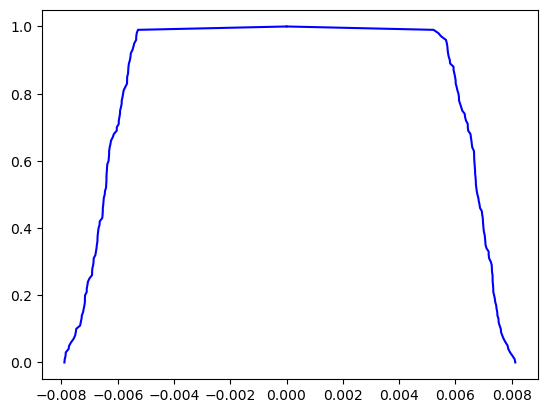

In [7]:
fig, ax = plt.subplots()
ax.plot(dico['DPneg']['deltas'], dico['DPneg']['survival'], color='blue')
ax.plot(dico['DPpos']['deltas'], dico['DPpos']['survival'], color='blue')

In [8]:
vars = line.vars.get_table()

In [13]:
vars.rows['.*qh.*']

VarsTable: 2 rows, 3 cols
name                value expr
kmkqh11653              0 None
qh_setvalue         20.13 None